# The Crude Unit as a Planning Block

A refinery LP models its crude unit as **base yields plus shift vectors**: how each
product's rate and quality moves when a cut point is moved, a pumparound is turned up or the
furnace is fired harder. In a commercial planning model those vectors come from perturbing a
rigorous simulator one variable at a time, and they are refreshed rarely, because each
refresh costs a column solve per lever and an engineer's afternoon.

This notebook builds them from a rigorous, differentiable 30-stage atmospheric column
(`difflow_refinery`) instead. Each delta vector is the column's own derivative, computed by
automatic differentiation through its Newton solve. The trust-region planner of
`difflow.planning` then recomputes them at every iterate (see
`30_delta_base_planning.ipynb` for that machinery on a simpler chain).

The notebook covers four things:

1. **The block.** `difflow_refinery.planning.cdu_block` names its levers and outputs by
   what they mean, such as `naphtha.yield`, `pa1.duty` and `kero.tbp95`. It carries them in
   the units a planner writes rows in: bbl/d, MW, °C for temperatures and K for
   temperature differences.
2. **Whether the vectors are right.** They are checked against central differences, and a
   health check looks for constant rows and kinks.
3. **A plan.** A network of CDU → product value is solved and then re-scored in a fresh
   nonlinear column solve.
4. **What happens when the column fails.** A column has operating points with no solution.
   Driving the planner into that region shows the proposal is rejected rather than scored.

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tabulate import tabulate

import difflow_refinery as dr
from difflow_refinery import Assay, characterize
from difflow_refinery import column as cc
from difflow_refinery.thermo import ColumnThermo
from difflow_refinery.planning import (available_levers, cdu_block, link_cdu,
                                       product_value_block)
from difflow.planning import (DeltaBasePlanner, Network, check_delta_health,
                              check_delta_vectors, draw_delta_vectors,
                              linearize_block)
from difflow.planning.lp import Spec
from difflow.planning.planner import TrustRegionOptions

plt.rcParams.update({"figure.figsize": (7.0, 4.0), "figure.dpi": 110})


def table(rows, headers, floatfmt="g"):
    display(Markdown(tabulate(rows, headers=headers, tablefmt="github", floatfmt=floatfmt)))

## 1. The crude unit

This is the test crude and column used throughout the refinery test suite:

- a 30-stage atmospheric tower with a partial condenser;
- three side strippers: kero, diesel and AGO;
- two pumparounds;
- bottom steam;
- a 5 % overflash.

The column is closed by **specs**:

- four product rates, written as volume fractions of the crude;
- two pumparound duties;
- two pumparound temperature drops;
- the overflash.

The specs decide what the planning levers can be. A spec value is something the planner may
move. A quantity the column computes is something the planner can only constrain.

In [2]:
PCT = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
T_C = [-10, 60, 95, 150, 205, 260, 315, 370, 430, 500, 600, 680, 850]
assay = Assay(PCT, [t + 273.15 for t in T_C], sg=0.86,
              light_ends={"propane": 0.5, "n_butane": 1.0, "n_pentane": 1.5})
BPD = 95_000.0                         # bbl/d
T_IN, P_IN = 273.15 + 240.0, 6e5       # furnace inlet: K, Pa

crude = characterize(assay)
thermo = ColumnThermo.from_characterization(crude)
Vf = BPD * cc.BARREL / 86400.0         # crude, std m3/s: product-rate specs are absolute
params = cc.CrudeColumnParams(
    n_stages=30, feed_stage=27, P_top=1.5e5, P_bottom=1.9e5, P_condenser=1.3e5,
    bottom_steam=150.0, steam_T=273.15 + 260.0,                     # mol/s
    side_products=(cc.SideProduct("kero", 9, 4, steam=40.0),
                   cc.SideProduct("diesel", 16, 4, steam=40.0),
                   cc.SideProduct("ago", 22, 3, steam=20.0)),
    pumparounds=(cc.Pumparound("pa1", 12, 10), cc.Pumparound("pa2", 19, 17)),
    specs=(cc.product_rate("naphtha", 0.20 * Vf), cc.product_rate("kero", 0.11 * Vf),
           cc.product_rate("diesel", 0.17 * Vf), cc.product_rate("ago", 0.05 * Vf),
           cc.pumparound_duty("pa1", 15e6), cc.pumparound_delta_t("pa1", 60.0),
           cc.pumparound_duty("pa2", 20e6), cc.pumparound_delta_t("pa2", 60.0),
           cc.overflash(0.05)),
)
unit = dr.CrudeUnit(assay, params)

t0 = time.perf_counter()
base = unit.solve(BPD, T=T_IN, P=P_IN)
print(f"converged: {bool(base.converged)}   ({time.perf_counter() - t0:.1f} s, eager)")
print(base.table())

converged: True   (11.9 s, eager)
product        bbl/d  vol %   wt %    API  TBP5 C  TBP50 C  TBP95 C
naphtha        19000   20.0   16.8   64.5       0       95      157
kero           10450   11.0   10.1   47.0     131      183      227
diesel         16150   17.0   16.5   38.0     194      259      321
ago             4750    5.0    5.1   30.9     274      333      378
residue        44650   47.0   51.5   18.7     323      474      754

coil outlet 314.8 C, 69.1 mol% vaporised; furnace 43.9 MW absorbed, 51.6 MW fired
condenser 32.4 MW, pumparounds 15.0, 20.0 MW


## 2. Levers and outputs

`available_levers(unit)` lists every lever this column offers. The list follows from the
specs and the steam points:

- the crude rate and the preheat temperature are always levers;
- each volume product-rate spec gives a `.yield` lever (a fraction of the crude) and a
  `.bpd` lever;
- each pumparound spec gives a lever in MW or K;
- each stripping-steam rate gives a lever in kg/h.

A column closed by an overflash has **no** coil-outlet-temperature lever. Fixing the coil
outlet as well would over-specify the column, so the planner moves the overflash and reads
the coil outlet off as an output.

In [3]:
rows = [(lv.name, lv.units, lv.description) for lv in available_levers(unit).values()]
table(rows, ["lever", "units", "what it moves"])

| lever         | units   | what it moves                                    |
|---------------|---------|--------------------------------------------------|
| crude.rate    | bbl/d   | crude charge                                     |
| preheat.T     | C       | furnace inlet temperature (preheat train outlet) |
| bottom.steam  | kg/h    | bottom stripping steam                           |
| kero.steam    | kg/h    | kero stripper steam                              |
| diesel.steam  | kg/h    | diesel stripper steam                            |
| ago.steam     | kg/h    | ago stripper steam                               |
| naphtha.yield | -       | naphtha rate as a volume fraction of the crude   |
| naphtha.bpd   | bbl/d   | naphtha rate                                     |
| kero.yield    | -       | kero rate as a volume fraction of the crude      |
| kero.bpd      | bbl/d   | kero rate                                        |
| diesel.yield  | -       | diesel rate as a volume fraction of the crude    |
| diesel.bpd    | bbl/d   | diesel rate                                      |
| ago.yield     | -       | ago rate as a volume fraction of the crude       |
| ago.bpd       | bbl/d   | ago rate                                         |
| pa1.duty      | MW      | heat removed by pumparound pa1                   |
| pa1.dT        | K       | pumparound pa1 draw less return temperature      |
| pa2.duty      | MW      | heat removed by pumparound pa2                   |
| pa2.dT        | K       | pumparound pa2 draw less return temperature      |
| overflash     | -       | overflash, volume fraction of the crude          |

The block below has four levers:

- the crude rate;
- the naphtha and kero yields, which act as the two front cut points;
- the duty of the upper pumparound.

It uses the default outputs. A spec that is *not* a lever is held at its base value. A held
product rate is held **as a yield**, so diesel and AGO stay at 17 % and 5 % of whatever
crude rate the plan chooses. Holding them as absolute rates would give the whole rate change
to the residue.

`jit=True` (the default) compiles the column once, through `blk.evaluate` and the
Jacobian. After that, an evaluation costs a fraction of a second. `blk.fn`, the uncompiled
model, takes about 2 s per call.

In [4]:
t0 = time.perf_counter()
blk = cdu_block(unit, ["crude.rate", "naphtha.yield", "kero.yield", "pa1.duty"],
                rate=BPD, T=T_IN, P=P_IN)
y0 = np.asarray(blk.evaluate(blk.u0))        # the block's compiled evaluation
print(f"built and compiled in {time.perf_counter() - t0:.1f} s")
t0 = time.perf_counter(); np.asarray(blk.evaluate(blk.u0 * 1.001))
print(f"one compiled evaluation: {time.perf_counter() - t0:.2f} s")

table(list(zip(blk.u_names, blk.metadata["u_units"], blk.u0, blk.lb, blk.ub)),
      ["lever", "units", "base", "lower", "upper"])
table([(n, u, v) for n, u, v in zip(blk.y_names, blk.metadata["y_units"], y0)],
      ["output", "units", "base"], floatfmt=".4g")

built and compiled in 5.8 s
one compiled evaluation: 0.17 s


| lever         | units   |     base |     lower |      upper |
|---------------|---------|----------|-----------|------------|
| crude.rate    | bbl/d   | 95000    | 85500     | 104500     |
| naphtha.yield | -       |     0.2  |     0.18  |      0.22  |
| kero.yield    | -       |     0.11 |     0.099 |      0.121 |
| pa1.duty      | MW      |    15    |    13.5   |     16.5   |

| output           | units   |         base |
|------------------|---------|--------------|
| naphtha.bpd      | bbl/d   |    1.9e+04   |
| naphtha.api      | API     |   64.52      |
| naphtha.tbp95    | C       |  157.5       |
| kero.bpd         | bbl/d   |    1.045e+04 |
| kero.api         | API     |   47         |
| kero.tbp5        | C       |  130.7       |
| kero.tbp95       | C       |  227.4       |
| diesel.bpd       | bbl/d   |    1.615e+04 |
| diesel.api       | API     |   37.95      |
| diesel.tbp5      | C       |  194.2       |
| diesel.tbp95     | C       |  321.3       |
| ago.bpd          | bbl/d   | 4750         |
| ago.api          | API     |   30.9       |
| ago.tbp5         | C       |  274.2       |
| ago.tbp95        | C       |  378.2       |
| residue.bpd      | bbl/d   |    4.465e+04 |
| residue.yield    | -       |    0.47      |
| residue.api      | API     |   18.66      |
| residue.tbp5     | C       |  323         |
| residue.tbp95    | C       |  753.6       |
| gap.naphtha_kero | K       |  -26.82      |
| gap.kero_diesel  | K       |  -33.21      |
| gap.diesel_ago   | K       |  -47.03      |
| gap.ago_residue  | K       |  -55.15      |
| cut.naphtha_kero | C       |  150         |
| cut.kero_diesel  | C       |  210.5       |
| cut.diesel_ago   | C       |  304         |
| cut.ago_residue  | C       |  331.4       |
| furnace.fired    | MW      |   51.59      |

The outputs follow a few conventions:

- `gap.<a>_<b>` is the 5–95 gap, TBP5 of the heavier product less TBP95 of the lighter, in K.
  Positive means a clean separation; this column overlaps everywhere.
- `cut.<a>_<b>` is the **effective cut point**: the crude's own TBP at the cumulative yield
  taken through the lighter product. It is what a planner means by "the kero/diesel cut",
  and it depends only on the yields.
- Units are in `blk.metadata["u_units"]` and `["y_units"]`. `difflow.planning.export` writes
  them into every export format.

## 3. Are the delta vectors right?

`check_delta_vectors` compares the AD Jacobian with central differences, using a step of
1e-5 of each lever's range.

passed: True   max error relative to the largest entry: 5.6e-10   (5.9 s)


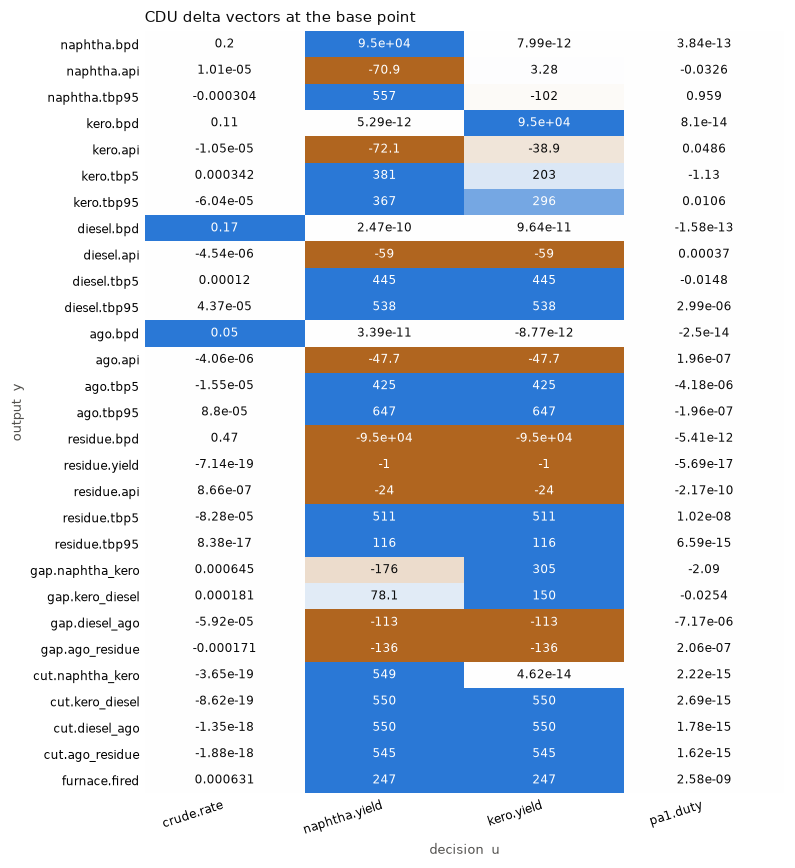

In [5]:
t0 = time.perf_counter()
chk = check_delta_vectors(blk)
print(f"passed: {chk['passed']}   max error relative to the largest entry: "
      f"{chk['max_rel_error']:.1e}   ({time.perf_counter() - t0:.1f} s)")

lin = linearize_block(blk, blk.u0)
ax = draw_delta_vectors(lin, block=blk, title="CDU delta vectors at the base point")
ax.figure.set_size_inches(7.5, 9.0)

The matrix reads as a planner would expect:

- **Naphtha yield**, the first cut, raises naphtha TBP95 and the naphtha/kero cut point
  (about 5.5 °C per point of yield). The kero starts heavier, so its TBP5 and TBP95 rise
  too.
- **Kero yield** raises kero TBP95 by about 3 °C per point of yield. This is the row a
  kero end-point spec will bind on.
- **PA1 duty** mainly moves the naphtha/kero split. Each MW raises naphtha TBP95 by about
  1 K and lowers kero TBP5 by about 1 K, so the overlap widens. It barely touches the kero
  end point.
- **Crude rate** moves every rate in proportion. It barely moves the qualities: tenths of a
  K per 1000 bbl/d. With the yields held, the cuts hardly change, and what is left is the
  column running harder at fixed pumparound duties.

## 4. Health

`check_delta_health` looks for three problems:

- dead levers and outputs;
- recycle amplification;
- scale spread.

The default outputs are chosen so that it comes back clean. Two kinds of output are left out
of the defaults on purpose.

In [6]:
print(check_delta_health(blk))

# the two kinds the defaults leave out, asked for explicitly:
held = cdu_block(unit, ["crude.rate"], ["diesel.yield", "diesel.bpd"], rate=BPD, T=T_IN, P=P_IN)
for f in check_delta_health(held).findings:
    print(f)

HealthReport(findings=0, errors=0, blocks=['cdu'])


[warning] dead_output: cdu.diesel.yield: delta row is structurally zero (max scaled sensitivity 3.415e-16); this output is a constant to the LP. If it carries a price or appears in a spec, the plan is being made against a number that cannot move.


The first kind is the **yield of a held product**. Holding the spec holds the yield, so its
row of delta vectors is exactly zero. The bbl/d of the same product is not a constant, because
it follows the crude rate. The defaults therefore report `.bpd` and leave out the held `.yield`.

The second kind is the **TBP5 of the lightest product**. A TBP point is piecewise linear in the
product's cumulative volume, with one node per component. Among the discrete light ends the
segments are tens of degrees wide. At this base point the naphtha's 5 % point sits *exactly*
on the n-butane node, so its slope is one-sided:

slope left of 0.20:  277.6 K per unit yield


slope right       :  146.2 K per unit yield


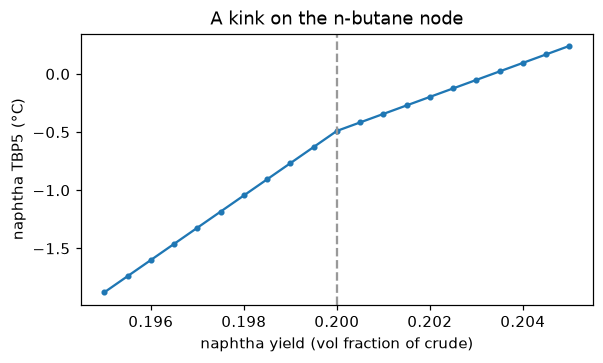

In [7]:
k = cdu_block(unit, ["naphtha.yield"], ["naphtha.tbp5"], rate=BPD, T=T_IN, P=P_IN)
x = np.linspace(0.195, 0.205, 21)
f = lambda v: float(k.evaluate(np.array([v]))[0])
tb5 = np.array([f(v) for v in x])
h = 1e-3
print(f"slope left of 0.20: {(f(0.2) - f(0.2 - h)) / h:6.1f} K per unit yield")
print(f"slope right       : {(f(0.2 + h) - f(0.2)) / h:6.1f} K per unit yield")
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(x, tb5, "o-", ms=3)
ax.axvline(0.2, color="0.6", ls="--")
ax.set_xlabel("naphtha yield (vol fraction of crude)")
ax.set_ylabel("naphtha TBP5 (°C)")
ax.set_title("A kink on the n-butane node");

At such a kink the AD derivative is one of the two one-sided slopes, and a central
difference averages the two. They disagree, which is correct. A planner that needs the front
end of the naphtha should constrain its vapour pressure. The 5 % point is not the right handle.

## 5. A plan: CDU → product value

The downstream block prices the products in \$/bbl. `link_cdu` wires each CDU output to the
input of the same name. The planner's objective has three parts:

- revenue;
- less crude, at \$65/bbl;
- less fuel, at \$700 per MW-day fired.

Two quality limits apply, each as a planner spec on a CDU output:

- kero TBP95 ≤ 235 °C (a jet end point);
- naphtha TBP95 ≤ 165 °C.

The levers are the crude rate, the two front yields and the overflash.

In [8]:
PRODUCTS = ["naphtha", "kero", "diesel", "ago", "residue"]
PRICES = {"naphtha": 70.0, "kero": 95.0, "diesel": 90.0, "ago": 80.0, "residue": 55.0}   # $/bbl

cdu = cdu_block(unit, ["crude.rate", "naphtha.yield", "kero.yield", "overflash"],
                [f"{p}.bpd" for p in PRODUCTS]
                + ["naphtha.tbp95", "kero.tbp95", "gap.kero_diesel", "furnace.fired"],
                rate=BPD, T=T_IN, P=P_IN,
                bounds={"crude.rate": (85_000.0, 100_000.0), "naphtha.yield": (0.17, 0.23),
                        "kero.yield": (0.08, 0.15), "overflash": (0.03, 0.07)})
value = product_value_block(PRICES, rates={p: float(base.properties[p].bpd) for p in PRODUCTS})
net = Network([cdu, value], link_cdu(cdu, value))
prices = {"value.revenue": 1.0, "cdu.crude.rate": -65.0, "cdu.furnace.fired": -700.0}
specs = [Spec("cdu.kero.tbp95", "<=", 235.0), Spec("cdu.naphtha.tbp95", "<=", 165.0)]

print(net)
for link in net.links:
    print("  link:", link)
print(check_delta_health(net))

Network(blocks=['cdu', 'value'], links=5, n_decisions=4)
  link: Link(source='cdu.naphtha.bpd', target='value.naphtha.bpd')
  link: Link(source='cdu.kero.bpd', target='value.kero.bpd')
  link: Link(source='cdu.diesel.bpd', target='value.diesel.bpd')
  link: Link(source='cdu.ago.bpd', target='value.ago.bpd')
  link: Link(source='cdu.residue.bpd', target='value.residue.bpd')


HealthReport(findings=0, errors=0, blocks=['<composed>', 'cdu', 'value'])


In [9]:
planner = DeltaBasePlanner(net, prices=prices, specs=specs,
                           options=TrustRegionOptions(radius=0.3, radius_min=1e-4, tol=1e-6),
                           vertex_seeding=False)
print(planner.describe())

Planning problem: maximise the priced objective

    1 value.revenue - 65 cdu.crude.rate - 700 cdu.furnace.fired

  by choosing 4 decisions (a trust region lets each move 0.3 of its bound range per cycle):
    cdu.crude.rate             start    9.5e+04   in [85000, 100000]      step +/- 4.5e+03
    cdu.naphtha.yield          start        0.2   in [0.17, 0.23]         step +/- 0.018
    cdu.kero.yield             start       0.11   in [0.08, 0.15]         step +/- 0.021
    cdu.overflash              start       0.05   in [0.03, 0.07]         step +/- 0.012

  everything else follows from the blocks (10 outputs, 5 links):
    value.naphtha.bpd          = cdu.naphtha.bpd   (not a free decision)
    value.kero.bpd             = cdu.kero.bpd   (not a free decision)
    value.diesel.bpd           = cdu.diesel.bpd   (not a free decision)
    value.ago.bpd              = cdu.ago.bpd   (not a free decision)
    value.residue.bpd          = cdu.residue.bpd   (not a free decision)
    not price

The convergence tolerance is `tol=1e-6`, a relative predicted improvement. The default of
1e-8 asks the LP to find \$0.005/d on a \$500,000/d margin, which is below the column's own
convergence noise. With the default, the loop keeps going at shrinking radius until it hits
its iteration cap.

In [10]:
t0 = time.perf_counter()
res = planner.solve()
print(f"{res.reason}, converged={res.converged}, {len(res.history)} iterations, "
      f"{time.perf_counter() - t0:.1f} s")
table([(h.index, h.radius, *np.round(h.decisions, 4), h.merit, h.rho, h.accepted)
       for h in res.history],
      ["it", "radius", *cdu.u_names, "merit $/d", "rho", "accepted"], floatfmt=".4g")

stationary, converged=True, 6 iterations, 3.2 s


|   it |   radius |   crude.rate |   naphtha.yield |   kero.yield |   overflash |   merit $/d |    rho | accepted   |
|------|----------|--------------|-----------------|--------------|-------------|-------------|--------|------------|
|    0 |      0.3 |     9.95e+04 |          0.2035 |       0.131  |       0.038 |   4.009e+05 | 0.4961 | True       |
|    1 |      0.3 |     1e+05    |          0.1855 |       0.1422 |       0.05  |   4.508e+05 | 1.002  | True       |
|    2 |      0.6 |     1e+05    |          0.1787 |       0.15   |       0.03  |   5.255e+05 | 0.9608 | True       |
|    3 |      0.6 |     1e+05    |          0.1786 |       0.15   |       0.03  |   5.48e+05  | 1      | True       |
|    4 |      0.6 |     1e+05    |          0.1786 |       0.15   |       0.03  |   5.488e+05 | 1      | True       |
|    5 |      0.6 |     1e+05    |          0.1786 |       0.15   |       0.03  |   5.488e+05 | 0      | False      |

In [11]:
start = res.history[0].merit
table([(n, f"{res.plan[n]:.4g}", u) for n, u in zip(res.plan, cdu.metadata["u_units"])],
      ["lever", "plan", "units"])
print(f"margin: {start:,.0f} -> {res.merit:,.0f} $/d")
s = res.state.values
for n in ["cdu.kero.tbp95", "cdu.naphtha.tbp95", "cdu.furnace.fired"]:
    print(f"{n:22s} {s[n]:9.3f}")

| lever             |        plan | units   |
|-------------------|-------------|---------|
| cdu.crude.rate    | 100000      | bbl/d   |
| cdu.naphtha.yield |      0.1786 | -       |
| cdu.kero.yield    |      0.15   | -       |
| cdu.overflash     |      0.03   | -       |

margin: 400,884 -> 548,819 $/d
cdu.kero.tbp95           235.000
cdu.naphtha.tbp95        145.544
cdu.furnace.fired         55.806


The plan is what the prices ask for:

- **Crude rate** goes to its upper bound, because every barrel earns more than it costs.
- **Kero yield** goes to its upper bound. Kero is the best-paid product.
- **Naphtha yield** comes *down*. Kero end point and naphtha yield are coupled: a heavier
  naphtha cut makes the kero heavier too. The planner gives up naphtha, which pays \$70,
  to keep the kero, which pays \$95, on its 235 °C limit.
- **Overflash** goes to its lower bound. It costs fuel, and here it does not pay for itself
  in kero quality.

**Re-scoring in the nonlinear column.** The planner already scores every accepted point in
the full blocks. As an independent check, the plan below is put through a *fresh* column
solve, from the column's own initial guess:

In [12]:
u = np.array([res.plan[f"cdu.{n}"] for n in cdu.u_names])
fresh = cdu.fn.solve(u)
y = cdu.fn.outputs_of(fresh)
print(f"fresh solve converged: {bool(fresh.converged)}   "
      f"residual {float(fresh.column.residual_norm):.1e}")
worst = max(abs(float(y[n]) - s[f"cdu.{n}"]) / max(1.0, abs(s[f"cdu.{n}"])) for n in cdu.y_names)
print(f"largest relative difference from the planner's state: {worst:.1e}")
print(fresh.table())

fresh solve converged: True   residual 1.1e-14
largest relative difference from the planner's state: 3.6e-15
product        bbl/d  vol %   wt %    API  TBP5 C  TBP50 C  TBP95 C
naphtha        17859   17.9   14.9   66.2      -6       89      146
kero           15000   15.0   13.8   47.1     129      181      235
diesel         17000   17.0   16.6   36.8     203      269      333
ago             5000    5.0    5.1   29.6     284      347      399
residue        45141   45.1   49.6   18.3     327      481      756

coil outlet 317.1 C, 69.7 mol% vaporised; furnace 47.4 MW absorbed, 55.8 MW fired
condenser 35.7 MW, pumparounds 15.0, 20.0 MW


## 6. When the column fails

Not every spec set has a solution. With 5 % overflash, taking more than about 25 MW out of
PA1 dries out the section above it: the reflux below the pumparound goes to zero and the
column's Newton solve fails. The column then reports `converged=False`, and its state is
finite but meaningless.

`cdu_block` returns **NaN** for every output at such a point. The planner treats any
non-finite block output as a model that **cannot be evaluated**, and acts on it in four ways:

- the proposal is rejected and the radius shrinks;
- this happens even with `accept_test=False`, because a point that cannot be evaluated
  cannot be linearised;
- a start point that cannot be evaluated loses to any start point that can;
- `solve()` raises if no start point can be evaluated.

The demonstration needs a price that pushes into the failed region. Here a credit of
\$1000 per MW-day is given for heat recovered in PA1:

In [13]:
def pa1_plan(mask):
    b = cdu_block(unit, ["pa1.duty"], ["naphtha.tbp95", "kero.tbp95", "furnace.fired"],
                  rate=BPD, T=T_IN, P=P_IN, bounds={"pa1.duty": (10.0, 30.0)},
                  mask_nonconverged=mask)
    p = DeltaBasePlanner(Network([b]), prices={"cdu.pa1.duty": 1000.0},
                         options=TrustRegionOptions(radius=0.3, radius_min=1e-2, tol=1e-6,
                                                    max_iter=30),
                         vertex_seeding=False)
    return b, p.solve()

b1, r1 = pa1_plan(mask=True)
table([(h.index, h.radius, h.decisions[0], bool(b1.fn.solve(h.decisions).converged),
        h.accepted, "not evaluable" if "not evaluable" in h.lp_status else "")
       for h in r1.history],
      ["it", "radius", "proposed PA1 MW", "column converges", "accepted", ""], floatfmt=".4g")
d = r1.plan["cdu.pa1.duty"]
print(f"plan: PA1 = {d:.2f} MW, column converged there: {bool(b1.fn.solve(np.array([d])).converged)}")

|   it |   radius |   proposed PA1 MW | column converges   | accepted   |               |
|------|----------|-------------------|--------------------|------------|---------------|
|    0 |  0.3     |             21    | True               | True       |               |
|    1 |  0.6     |             30    | False              | False      | not evaluable |
|    2 |  0.3     |             27    | False              | False      | not evaluable |
|    3 |  0.15    |             24    | True               | True       |               |
|    4 |  0.3     |             30    | False              | False      | not evaluable |
|    5 |  0.15    |             27    | False              | False      | not evaluable |
|    6 |  0.075   |             25.5  | False              | False      | not evaluable |
|    7 |  0.0375  |             24.75 | False              | False      | not evaluable |
|    8 |  0.01875 |             24.38 | True               | True       |               |
|    9 |  0.0375  |             25.12 | False              | False      | not evaluable |
|   10 |  0.01875 |             24.75 | False              | False      | not evaluable |

plan: PA1 = 24.38 MW, column converged there: True


Every proposal past the edge is rejected, and the plan closes on the edge from the converged
side. Below is the control: the same run with `mask_nonconverged=False`, where the block
reports the failed solve's numbers as if they were an answer.

In [14]:
b0, r0 = pa1_plan(mask=False)
d0 = r0.plan["cdu.pa1.duty"]
print(f"unmasked plan: PA1 = {d0:.2f} MW ({r0.reason}); "
      f"column converged there: {bool(b0.fn.solve(np.array([d0])).converged)}")

unmasked plan: PA1 = 30.00 MW (stationary); column converged there: False


Without the mask, the planner takes the bound at 30 MW and reports itself converged. The
column there did not converge, so the "plan" is a set of numbers no column produced.

## 7. Why yields are the levers, not cut-point targets

A refinery planner often states a CDU in cut points ("kero/diesel at 250 °C"). The block
gives cut points as **outputs** (`cut.*`, the TBP points and the gaps) and keeps the yields
as **levers**. There are three reasons:

- **The feasible set is the same.** A cut-point target is a row on an output. The LP inverts
  the delta vector to find the yield that meets it, as it did with the kero end point above.
- **Specs inside the column would be kinked.** Making a cut point a column spec would put a
  TBP point inside the column's Newton solve. As section 4 shows, a TBP point is piecewise
  linear, with kinks on component nodes.
- **The cost would multiply.** The alternative is a root find around the column, which means
  several column solves per evaluation.